In [ ]:
#NOMBRE: DIEGO JAVIER MORALES MONZÓN			CARNÉ: 1132119
#NOMBRE: ESTUARDO JOSÉ VILLEDA NAVARRO			CARNÉ: 1003519
#NOMBRE: JORGE WALDEMAR GARCÍA BALDIZÓN			CARNÉ: 1220019
#NOMBRE: JOSÉ DANIEL DE LEÓN CHANG				CARNÉ: 1170419

In [1]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

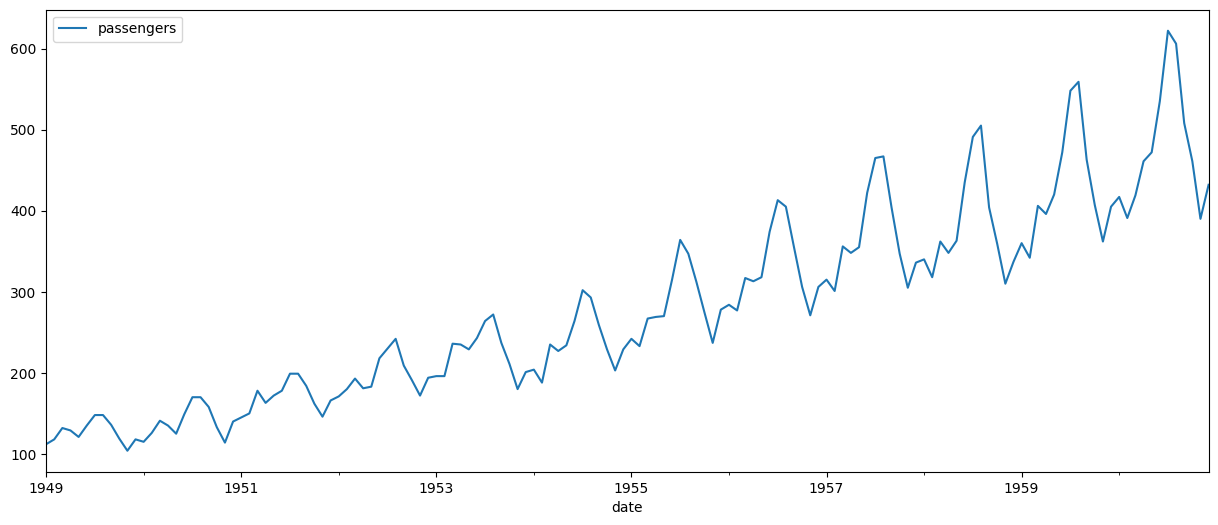

In [2]:
data = pd.read_csv('air_passengers.csv', sep=',')
df = pd.DataFrame(data, columns=['date', 'passengers'])

# Set the Date as Index
df['date'] = pd.to_datetime(df['date'])
df.index = df['date']
del df['date']

df.plot(figsize=(15, 6))
plt.show()

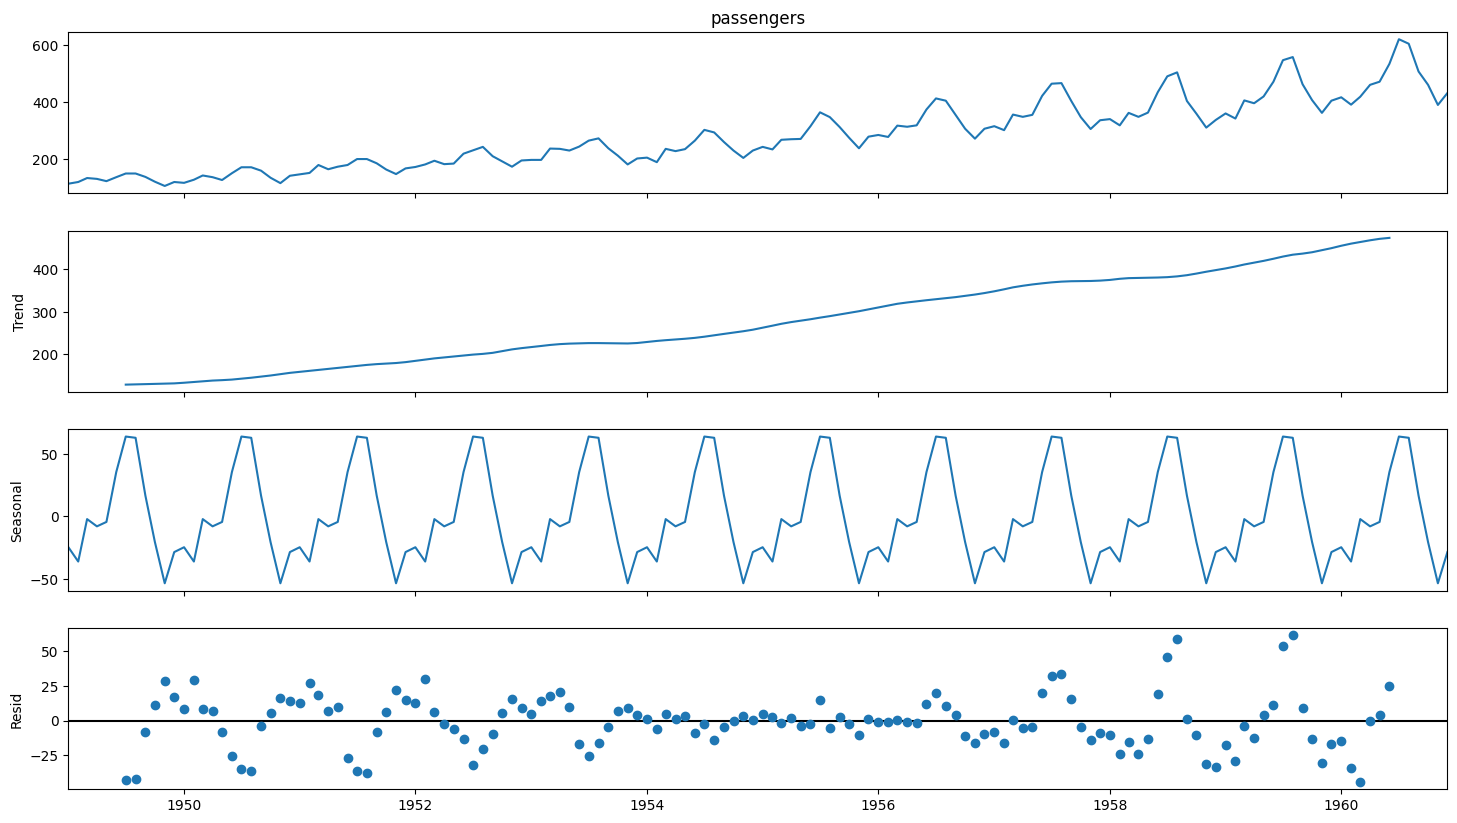

In [3]:
decompose = seasonal_decompose(df['passengers'], model='additive', period=12)

decompose_graph = decompose.plot()
decompose_graph.set_size_inches(16, 9)

plt.show()

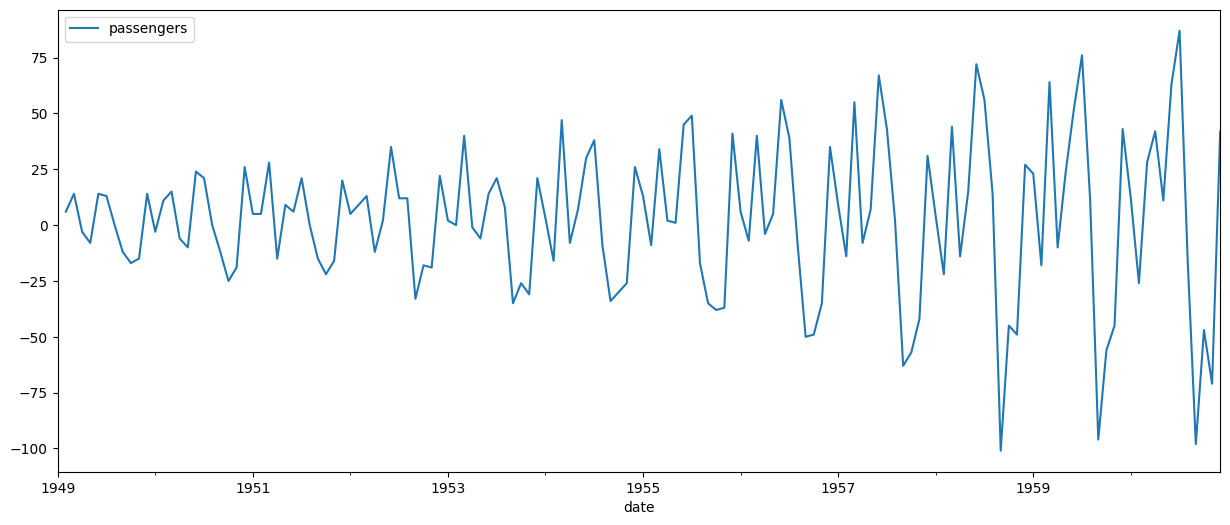

In [4]:
differenced_df = df.diff()

differenced_df.plot(figsize=(15, 6))
plt.show()

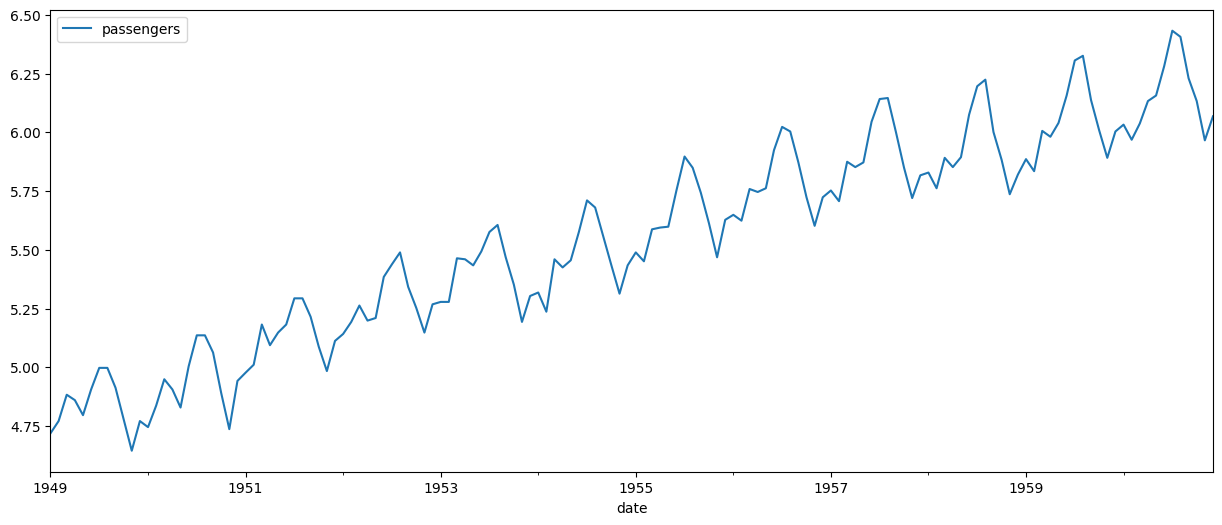

In [5]:
df_log = np.log(df)

df_log.plot(figsize=(15, 6))
plt.show()

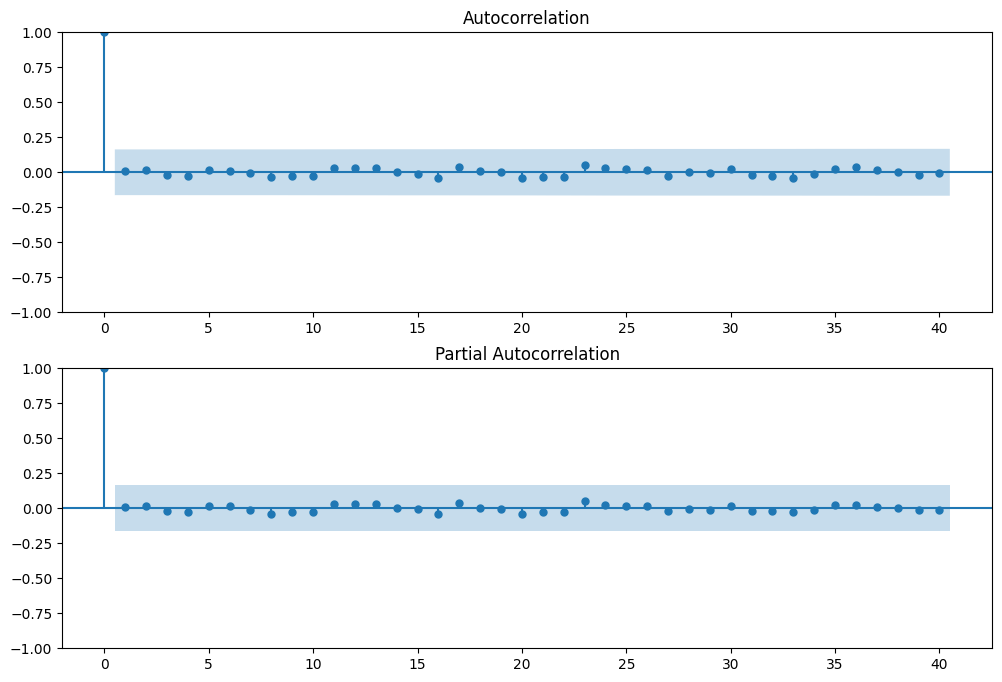

In [8]:
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(211)
plot_acf(model.resid, lags=40, ax=ax1)

ax2 = fig.add_subplot(212)
plot_pacf(model.resid, lags=40, ax=ax2)

plt.show()

In [9]:
arima_model = SARIMAX(df_log, trend='n', order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model = arima_model.fit()

print(model.summary())

C:\Users\jdele\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jdele\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 245.151
Date:                            Mon, 04 May 2026   AIC                           -480.303
Time:                                    19:35:27   BIC                           -465.927
Sample:                                01-01-1949   HQIC                          -474.461
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1615      0.213      0.757      0.449      -0.257       0.580
ma.L1         -0.5565      0.185   

<Axes: xlabel='date'>

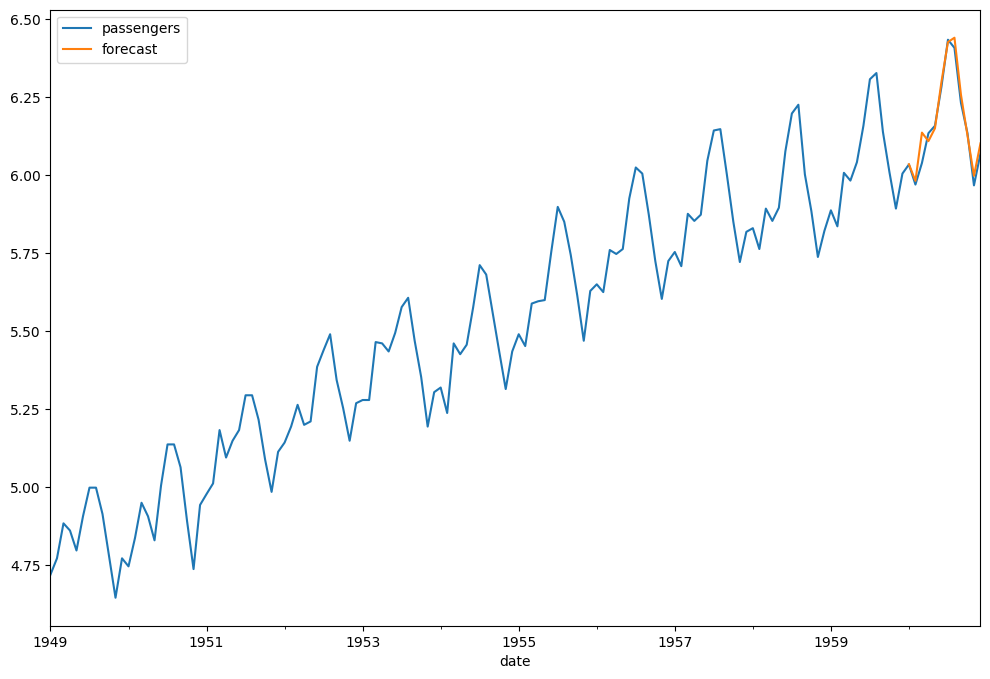

In [10]:
#Predicciones
predictions = df_log.copy()

predictions['forecast'] = model.predict(start=132, end=143, dynamic=True)

predictions[['passengers', 'forecast']].plot(figsize=(12, 8))

<Axes: xlabel='date'>

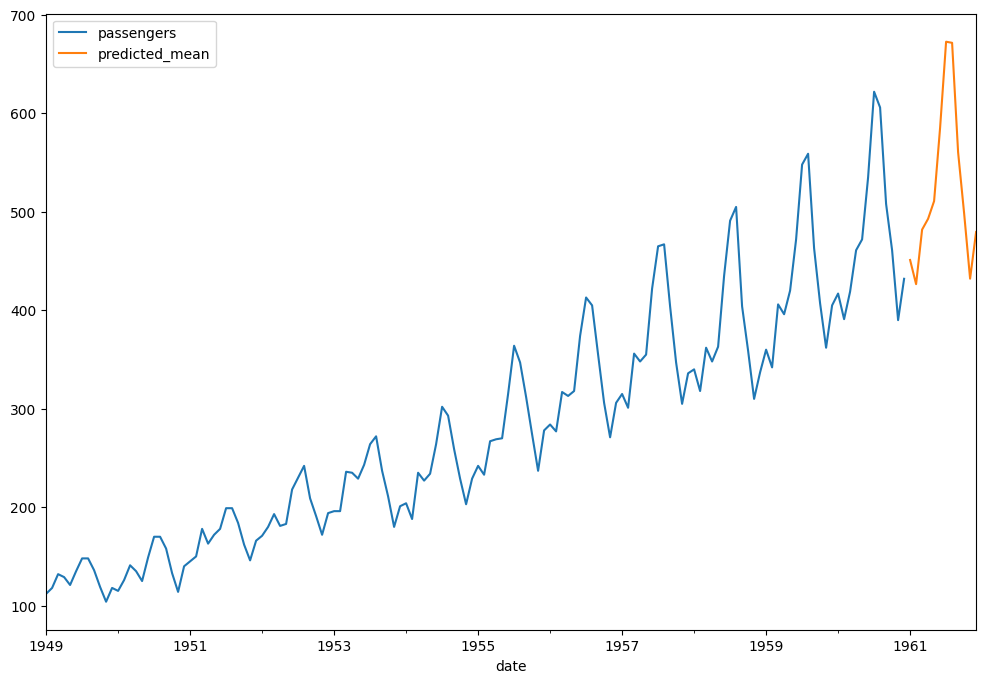

In [11]:
forecast = model.forecast(steps=12)

np.exp(df_log).plot(figsize=(12, 8), legend=True)
np.exp(forecast).plot(figsize=(12, 8), legend=True)